<a href="https://colab.research.google.com/github/LakshmiAhala/MachineLearning/blob/main/ML_Assign6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Importing Necessary Libraries

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Part 1: Study and Run the Linear Regression Example

Mean squared error: 2548.07
Coefficient of determination: 0.47


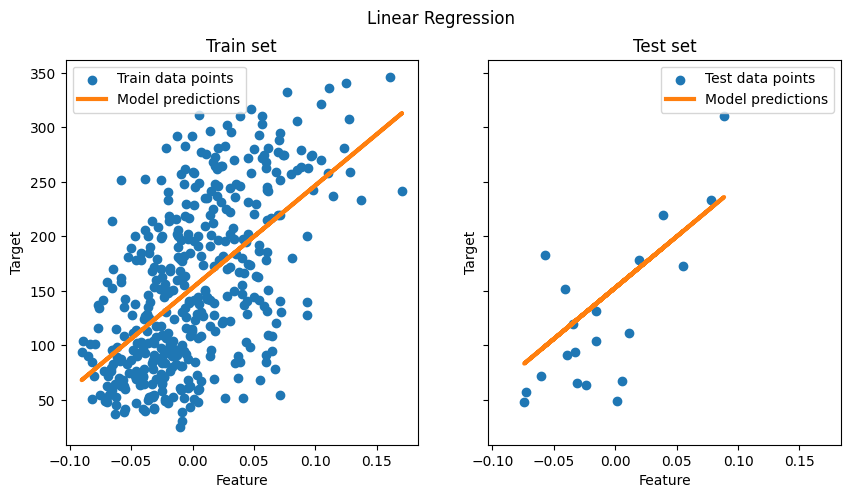

In [ ]:
#@title 1.1: Reproduce the Example
# Loading the diabetes dataset and preparing it for linear regression analysis
# Selecting only the third feature (BMI) to demonstrate simple linear regression
# The data is split into train and test sets with 20 samples reserved for testing

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn import datasets

X, y = load_diabetes(return_X_y=True)
# diabetes = datasets.load_diabetes()
# print(diabetes.DESCR)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)


# Training a linear regression model on the training data to learn the relationship
# between the selected feature and the target variable (diabetes progression).
# Then evaluating the model's performance using MSE and R² metrics on the test set.
regressor = LinearRegression().fit(X_train, y_train)
y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

# Visualizing the linear regression results by creating side-by-side plots.
# The left plot shows the training data with the fitted line, while the right
# plot displays the test data with predictions to assess model generalization.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

#Part 2: Modify and Experiment

[2, 5, 8]
Processing feature at index: 2


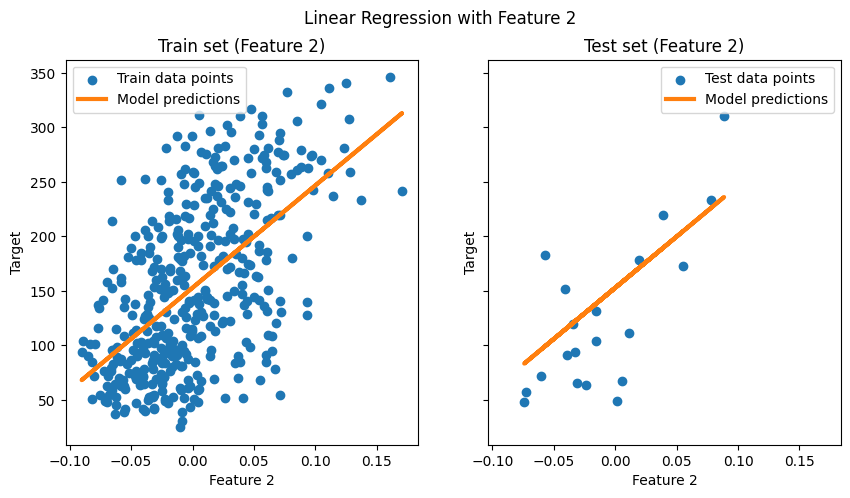

Processing feature at index: 5


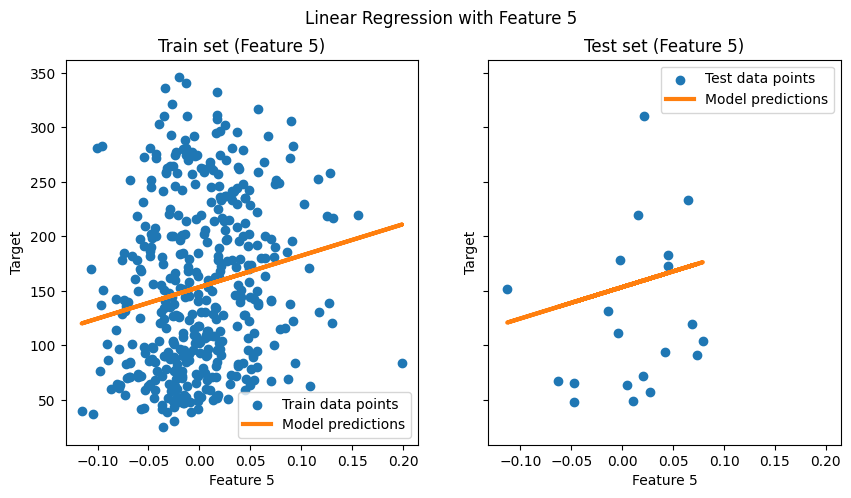

Processing feature at index: 8


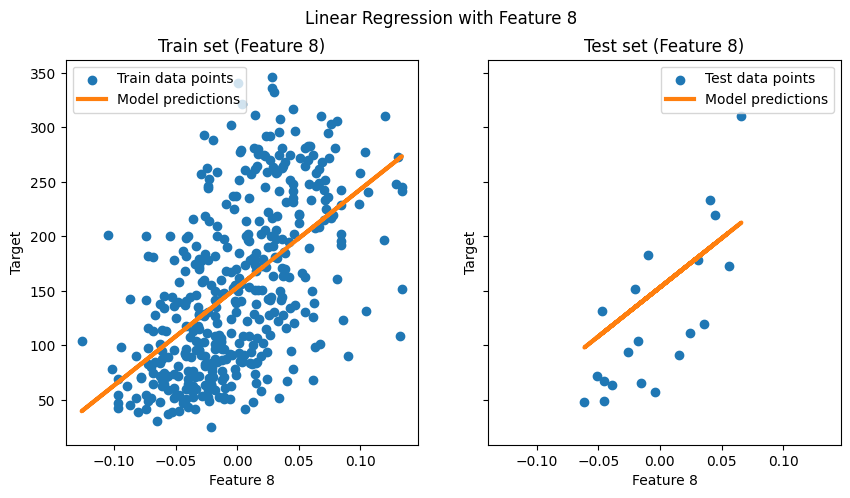


Comparison Table:


,feature_index,mse,r2
0,2,2548.072399,0.472575
1,5,5564.137342,-0.151719
2,8,2923.279360,0.394911


In [ ]:
#@title 2.1: Explore Different Features

# Loading the diabetes dataset
X, y = load_diabetes(return_X_y=True)

feature_indices = [2, 5, 8]
print(feature_indices)
results = []

# Looping through each feature
for index in feature_indices:
    print(f"Processing feature at index: {index}")

    # Selecting a single feature
    X_single_feature = X[:, index].reshape(-1, 1)

    # Splitting data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_single_feature, y, test_size=20, shuffle=False)

    # Training a linear regression model
    regressor = LinearRegression().fit(X_train, y_train)

    # Making predictions on the test set
    y_pred = regressor.predict(X_test)

    # Calculating MSE and R²
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({'feature_index': index, 'mse': mse, 'r2': r2})

    # Visualizing the linear regression results
    fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

    ax[0].scatter(X_train, y_train, label="Train data points")
    ax[0].plot(
        X_train,
        regressor.predict(X_train),
        linewidth=3,
        color="tab:orange",
        label="Model predictions",
    )
    ax[0].set(xlabel=f"Feature {index}", ylabel="Target", title=f"Train set (Feature {index})")
    ax[0].legend()

    ax[1].scatter(X_test, y_test, label="Test data points")
    ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
    ax[1].set(xlabel=f"Feature {index}", ylabel="Target", title=f"Test set (Feature {index})")
    ax[1].legend()

    fig.suptitle(f"Linear Regression with Feature {index}")

    plt.show()

# Create and display the comparison table
results_df = pd.DataFrame(results)
print("\nComparison Table:")
display(results_df)

##2.2: Observations for the below code

MSE: It is lowest for the smallest test size (10), increases for 20, and is the maximum at 50. Usually, a lower MSE indicates a better fit.

R²: It is lowest for the smallest test size (10), maximum for 20, and decreases for 50. A higher R² indicates that more of the variance in the target variable is explained by the model.

Increasing the test size from 20 to 50 resulted in an increase in MSE and a decrease in R². There isnt any exact relationship pattern between the testsize and the output.

Processing with test_size = 10


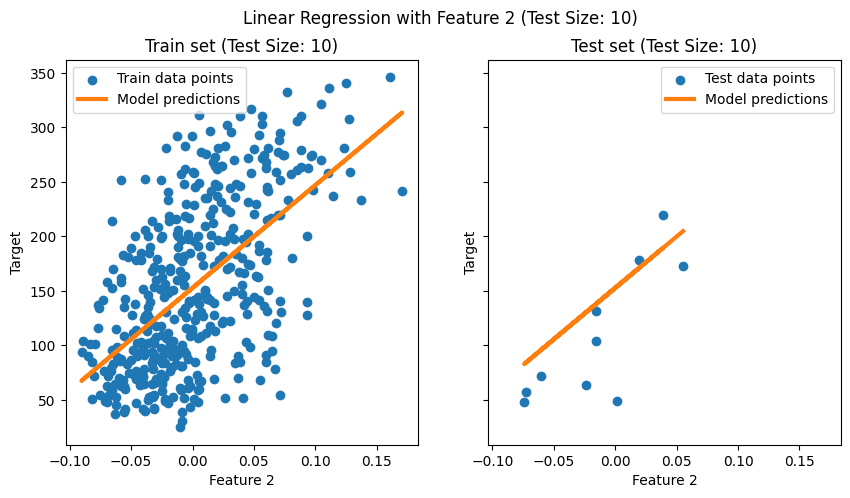

Processing with test_size = 20


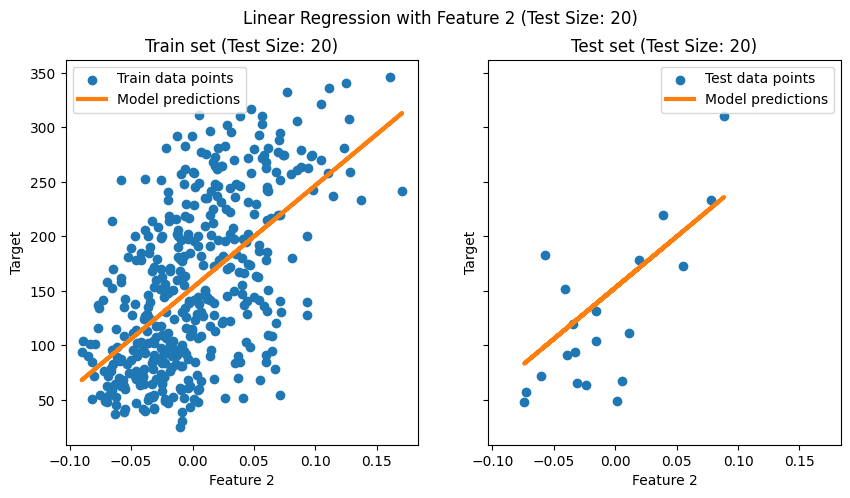

Processing with test_size = 50


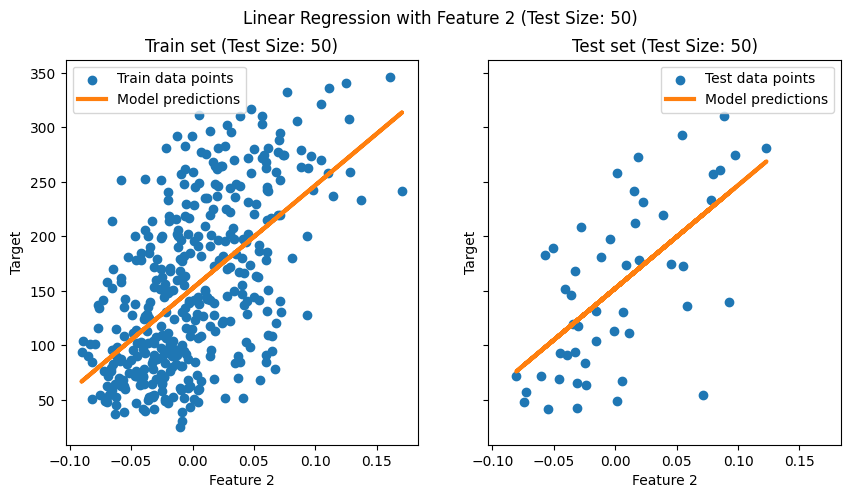


Comparison Table for Different Test Sizes:


,test_size,feature_index,mse,r2
0,10,2,2118.597123,0.397203
1,20,2,2548.072399,0.472575
2,50,2,3471.923196,0.412759


In [ ]:
#@title 2.2: Experiment with Test Set Size

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

test_sizes = [10, 20, 50]
feature_index = 2 # Using feature index 2 as in the previous experiment

all_results = []

for test_size in test_sizes:
    print(f"Processing with test_size = {test_size}")

    # Loading the diabetes dataset
    X, y = load_diabetes(return_X_y=True)

    # Selecting a single feature
    X_single_feature = X[:, feature_index].reshape(-1, 1)

    # Splitting data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_single_feature, y, test_size=test_size, shuffle=False)

    # Training a linear regression model
    regressor = LinearRegression().fit(X_train, y_train)

    # Making predictions on the test set
    y_pred = regressor.predict(X_test)

    # Calculating MSE and R²
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    all_results.append({'test_size': test_size, 'feature_index': feature_index, 'mse': mse, 'r2': r2})

    # Visualizing the linear regression results (optional - you can remove this if you only want the table)
    fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

    ax[0].scatter(X_train, y_train, label="Train data points")
    ax[0].plot(
        X_train,
        regressor.predict(X_train),
        linewidth=3,
        color="tab:orange",
        label="Model predictions",
    )
    ax[0].set(xlabel=f"Feature {feature_index}", ylabel="Target", title=f"Train set (Test Size: {test_size})")
    ax[0].legend()

    ax[1].scatter(X_test, y_test, label="Test data points")
    ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
    ax[1].set(xlabel=f"Feature {feature_index}", ylabel="Target", title=f"Test set (Test Size: {test_size})")
    ax[1].legend()

    fig.suptitle(f"Linear Regression with Feature {feature_index} (Test Size: {test_size})")

    plt.show()

# Create and display the comparison table
results_df = pd.DataFrame(all_results)
print("\nComparison Table for Different Test Sizes:")
display(results_df)


##2.3: Why did I choose what I chose below?

*   **-0.05:** This value is chosen to be near the lower end of the training data range.
*   **0.0:** This value is close to the center or mean of the training data for BMI.
*   **0.05:** This value is slightly above the center, representing a moderate BMI value within the range.
*   **0.12:** This value is chosen to be closer to the upper end of the training data range.
*   **0.16:** This value is very close to the upper limit of the training data range.

New data points created within the range of feature 2 training data:


array([[-0.05],
       [ 0.  ],
       [ 0.05],
       [ 0.12],
       [ 0.16]])



Predicted values for the new data points:
[105.05993727 152.33489819 199.60985911 265.7948044  303.61477314]


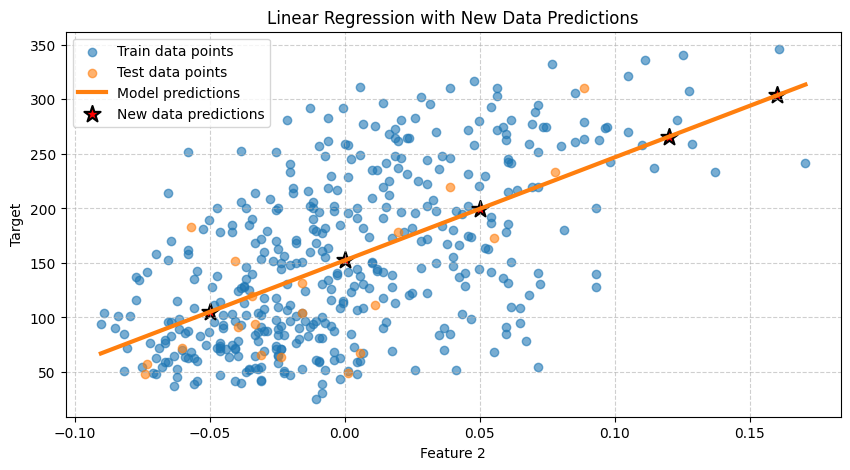

In [ ]:
#@title 2.3: Make Predictions on New Data

# Creating 5 new data points within this range
new_data_points = np.array([
    [-0.05],  # A value near the lower end of the range
    [0.0],    # A value near the center of the range (close to the mean)
    [0.05],   # A value slightly above the center
    [0.12],   # A value closer to the upper end
    [0.16]    # A value very close to the upper limit
])

print("New data points created within the range of feature 2 training data:")
display(new_data_points)

# Using trained model to make predictions on these points
#@title Make Predictions on New Data

# Use the trained regressor from the previous step (cell 2.2) to predict the target values for the new data points
predictions = regressor.predict(new_data_points)
print("\n\nPredicted values for the new data points:")
print(predictions)

###
#@title Visualize Predictions on New Data

# Ensure the regressor and new_data_points are available from previous cells
if 'regressor' in locals() and 'new_data_points' in locals():

    # Predict on the new data points
    predictions = regressor.predict(new_data_points)

    # Load the diabetes dataset again to get the original data for plotting
    X, y = load_diabetes(return_X_y=True)
    feature_index = 2 # Using feature index 2 as before
    X_single_feature = X[:, feature_index].reshape(-1, 1)

    # Split data into train and test sets (using a test size that was used before, e.g., 20)
    # This is just to get the train/test points for visualization
    X_train, X_test, y_train, y_test = train_test_split(X_single_feature, y, test_size=20, shuffle=False)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot training data
    ax.scatter(X_train, y_train, label="Train data points", alpha=0.6)

    # Plot test data
    ax.scatter(X_test, y_test, label="Test data points", alpha=0.6)

    # Plot the fitted line
    x_plot = np.linspace(X_single_feature.min(), X_single_feature.max(), 100).reshape(-1, 1)
    y_plot = regressor.predict(x_plot)
    ax.plot(x_plot, y_plot, color="tab:orange", linewidth=3, label="Model predictions")

    # Plot the new data points and their predictions
    ax.scatter(new_data_points, predictions, color='red', marker='*', s=150, label="New data predictions", edgecolor='black', linewidth=1.5)

    ax.set(xlabel=f"Feature {feature_index}", ylabel="Target", title="Linear Regression with New Data Predictions")
    ax.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#Part 3: Analysis and Understanding

Q1) How does Linear Regression (OLS) find the best-fit line? Explain the concept of minimizing squared errors and why we use "squared" errors rather than just errors

-- Linear Regression tries to find the best line using (y = mx + b). Here, best fit means trying to minimise the total error between predicted and actual values. We use squared errors because all errors become positive and large errors are penalized heavily.

Q2) What does the R² score tell you about model performance? What range of values can it take, and what do they mean? Give an example of what an R² of 0.0, 0.5, and 1.0 would indicate

-- R² measures how well your model explains the variance in data. It can range from any negative number to 1. An R² value of 0.0 would mean your model is as good as predicting the mean, 0.5 would mean it is moderate, and 1.0 would mean its perfect.

Q3) Compare MSE values across different features (from Task 2.1). Why might one feature be better than another for prediction? What characteristics might make a feature more predictive?

--Model 0 has the best MSE value of 2548.07. Features with less noise, clearer patterns, and a stronger relationship with the target variable are usually stronger. Relevance and domain knowledge, content, strong correlaition with the target variable, and variability are factors that make a feature more predictive.

